IMPORINT ALL NECESSaRY LIBRARY TO PERFORM THE PREPROCESSING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

loading the data in the jupyter notebook

In [2]:
data = pd.read_csv("../data/raw_data.csv")

performing simple checks before data cleaning  

In [3]:
print("shape of the dataset:", data.shape)

shape of the dataset: (1100, 7)


In [4]:
print("data types of the dataset:\n", data.dtypes)

data types of the dataset:
 Building Type              str
Square Footage           int64
Number of Occupants      int64
Appliances Used          int64
Average Temperature    float64
Day of Week                str
Energy Consumption     float64
dtype: object


In [5]:
print("data information:\n ")
data.describe()

data information:
 


,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,25500.527273,48.268182,25.730000,22.559745,4168.191273
std,14236.955632,29.127624,14.116209,7.122357,924.278723
min,560.000000,1.000000,1.000000,10.050000,1683.950000
25%,13203.750000,22.000000,13.000000,16.365000,3510.460000
50%,25785.500000,47.000000,26.000000,22.810000,4189.690000
75%,37536.750000,73.000000,38.000000,28.760000,4859.510000
max,49997.000000,99.000000,49.000000,34.990000,6530.600000


In [6]:
print("information about the dataset:\n ")
data.info()

information about the dataset:
 
<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1100 non-null   str    
 1   Square Footage       1100 non-null   int64  
 2   Number of Occupants  1100 non-null   int64  
 3   Appliances Used      1100 non-null   int64  
 4   Average Temperature  1100 non-null   float64
 5   Day of Week          1100 non-null   str    
 6   Energy Consumption   1100 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 60.3 KB


In [7]:
print("checking for duplicates in the dataset:\n ")
data.duplicated().sum()

checking for duplicates in the dataset:
 


np.int64(0)

In [8]:
print("checking for null values in the dataset:\n ")
data.isnull().sum()

checking for null values in the dataset:
 


Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

In [9]:
data.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [10]:
data.tail()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
1095,Commercial,1161,81,11,15.45,Weekend,3010.81
1096,Residential,37943,50,23,21.73,Weekend,4248.49
1097,Commercial,1558,27,29,16.86,Weekend,2843.60
1098,Industrial,2145,56,12,11.77,Weekend,3348.39
1099,Residential,42414,72,24,29.62,Weekday,4722.59


PERFROMING EDA(exploratory data analysis) ON THE DATASET!!

univariate analysis

([0, 1], [Text(0, 0, 'Weekday'), Text(1, 0, 'Weekend')])

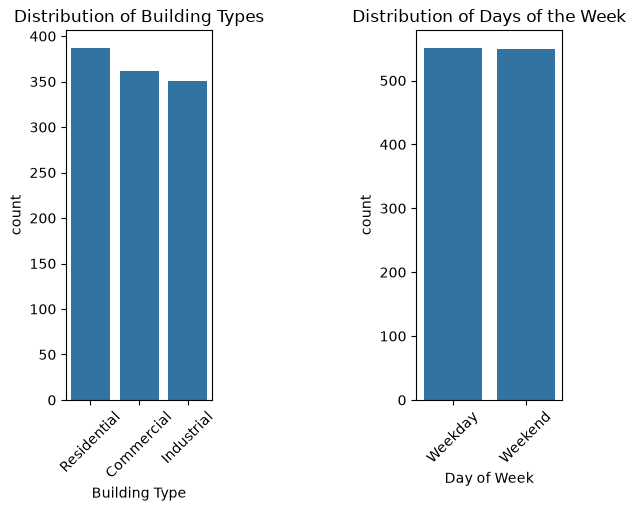

In [11]:
plt.subplot(1, 3, 1)
sns.countplot(x='Building Type', data=data)
plt.title('Distribution of Building Types')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.countplot(x='Day of Week', data=data)
plt.title('Distribution of Days of the Week')
plt.xticks(rotation=45)

(array([   0., 2000., 4000., 6000., 8000.]),
 [Text(0.0, 0, '0'),
  Text(2000.0, 0, '2000'),
  Text(4000.0, 0, '4000'),
  Text(6000.0, 0, '6000'),
  Text(8000.0, 0, '8000')])

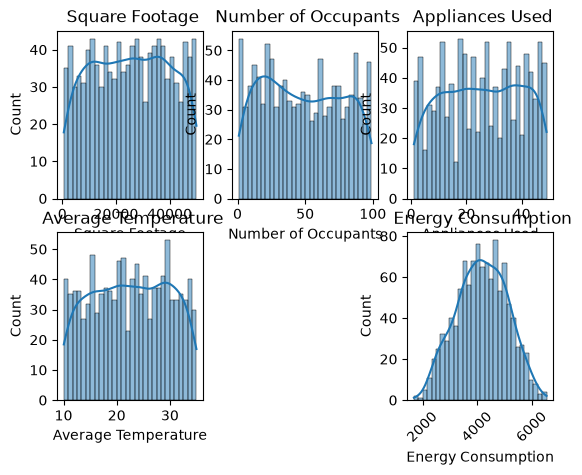

In [12]:
plt.subplot(2, 3, 1)
sns.histplot(data['Square Footage'], bins=30, kde=True)
plt.title(' Square Footage')


plt.subplot(2, 3, 2)
sns.histplot(data['Number of Occupants'], bins=30, kde=True)
plt.title(' Number of Occupants')

plt.subplot(2, 3, 3)
sns.histplot(data['Appliances Used'], bins=30, kde=True)
plt.title(' Appliances Used')

plt.subplot(2, 3, 4)
sns.histplot(data['Average Temperature'], bins=30, kde=True)
plt.title(' Average Temperature')

plt.subplot(2, 3, 6)
sns.histplot(data['Energy Consumption'], bins=30, kde=True)
plt.title(' Energy Consumption')
plt.xticks(rotation=45)

<Axes: ylabel='Energy Consumption'>

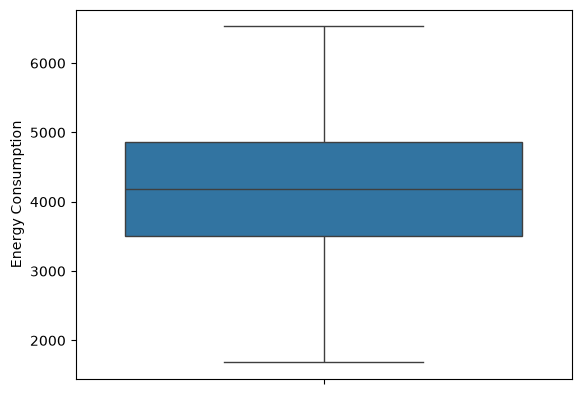

In [13]:
sns.boxplot(y='Energy Consumption', data=data)

.(bivariate and multivariate )Exploratory data analysis!!

<Axes: xlabel='Square Footage', ylabel='Energy Consumption'>

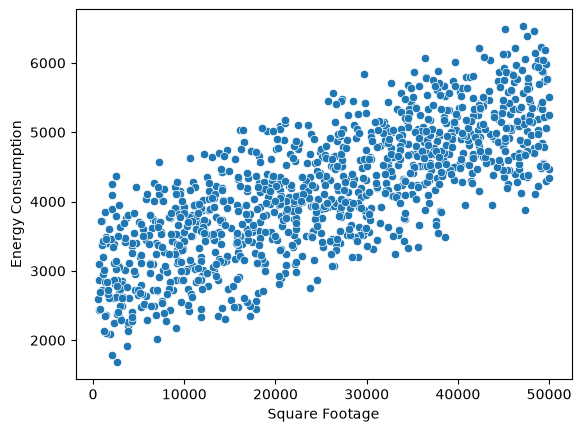

In [14]:
sns.scatterplot(x='Square Footage', y='Energy Consumption', data=data)

numnerical vs numerical features correlation:
 


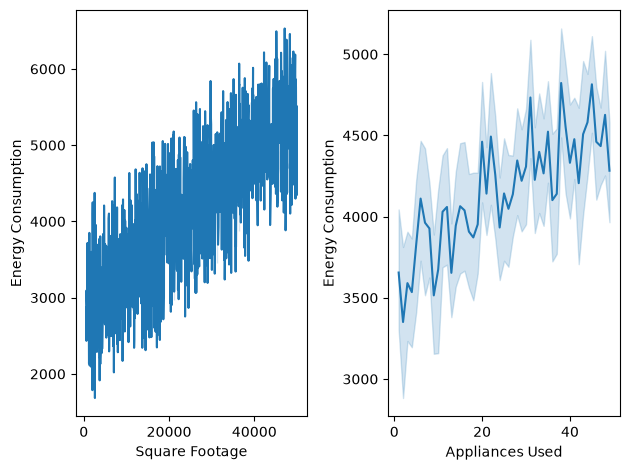

In [15]:
plt.subplot(1, 2, 1)
sns.lineplot(x='Square Footage', y='Energy Consumption', data=data)
plt.subplot(1, 2, 2)

sns.lineplot(x='Appliances Used', y='Energy Consumption', data=data)

plt.tight_layout()
print("numnerical vs numerical features correlation:\n ")

categorical vs numerical features correlation:
 


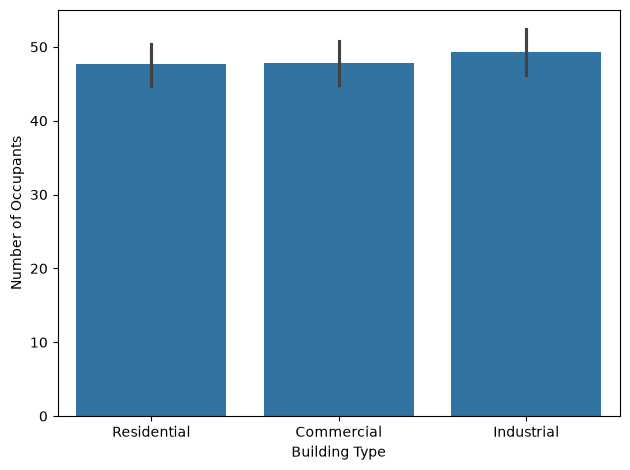

In [16]:

sns.barplot(x='Building Type', y='Number of Occupants', data=data)
plt.tight_layout()
print("categorical vs numerical features correlation:\n ")

categorical vs numerical features correlation:
 


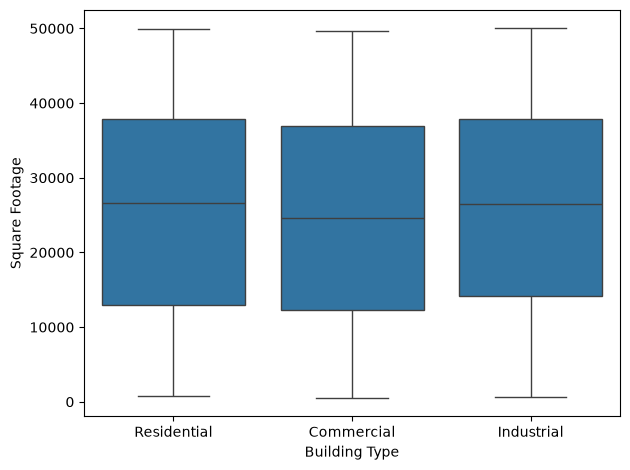

In [17]:

sns.boxplot(x='Building Type', y='Square Footage', data=data)
plt.tight_layout()
print("categorical vs numerical features correlation:\n ")

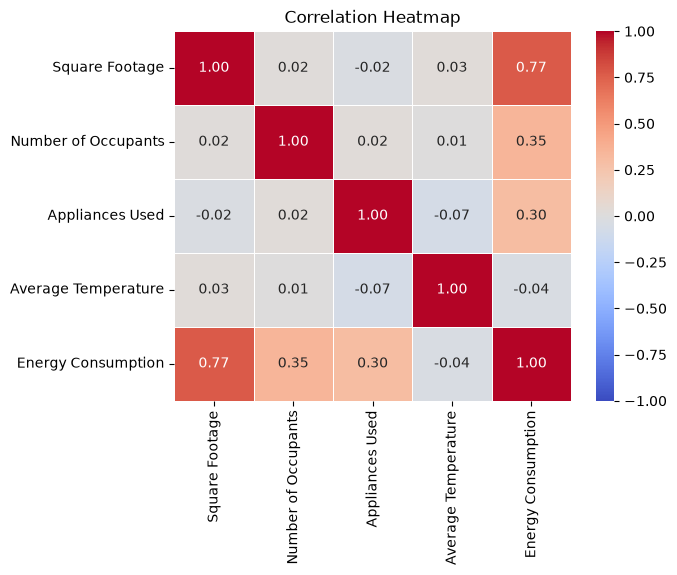

In [18]:


num_cols = ['Square Footage', 'Number of Occupants', 'Appliances Used',
            'Average Temperature', 'Energy Consumption']

sns.heatmap(data[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

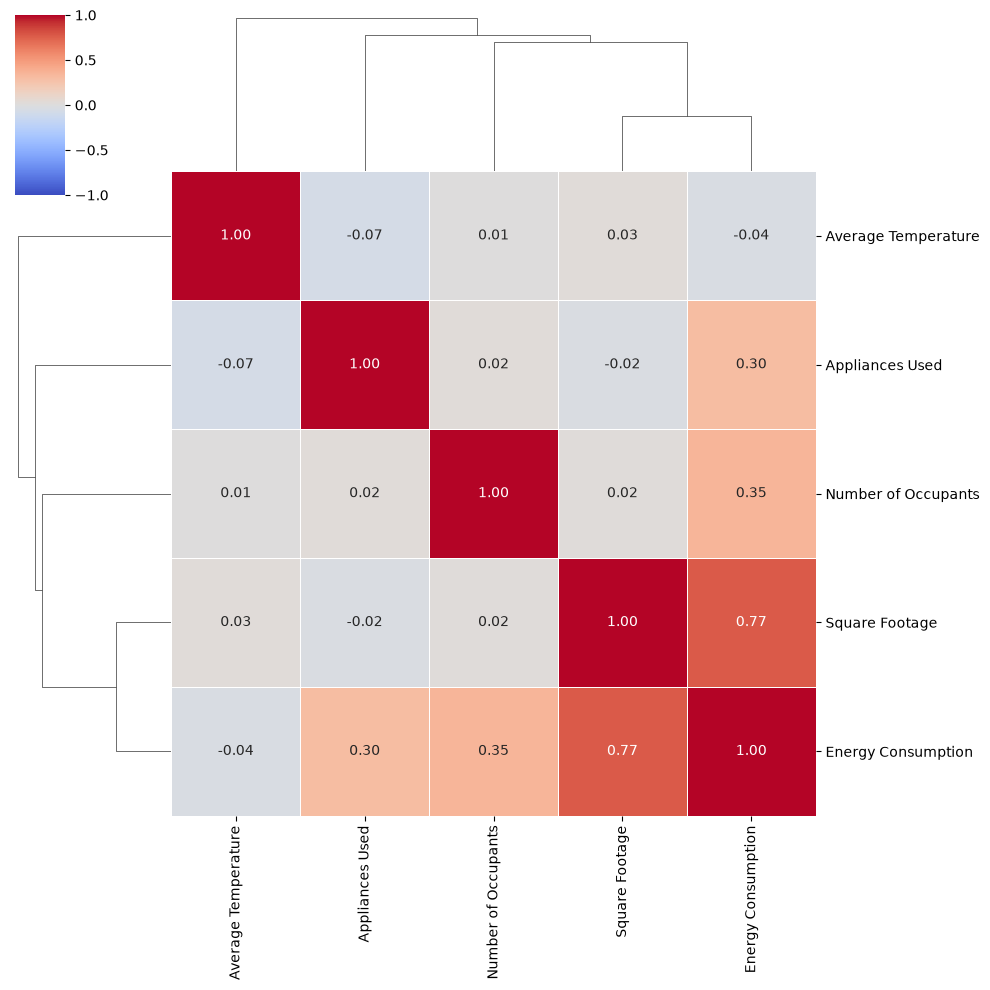

In [19]:
sns.clustermap(data[num_cols].corr(), annot=True, fmt='.2f',
               cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

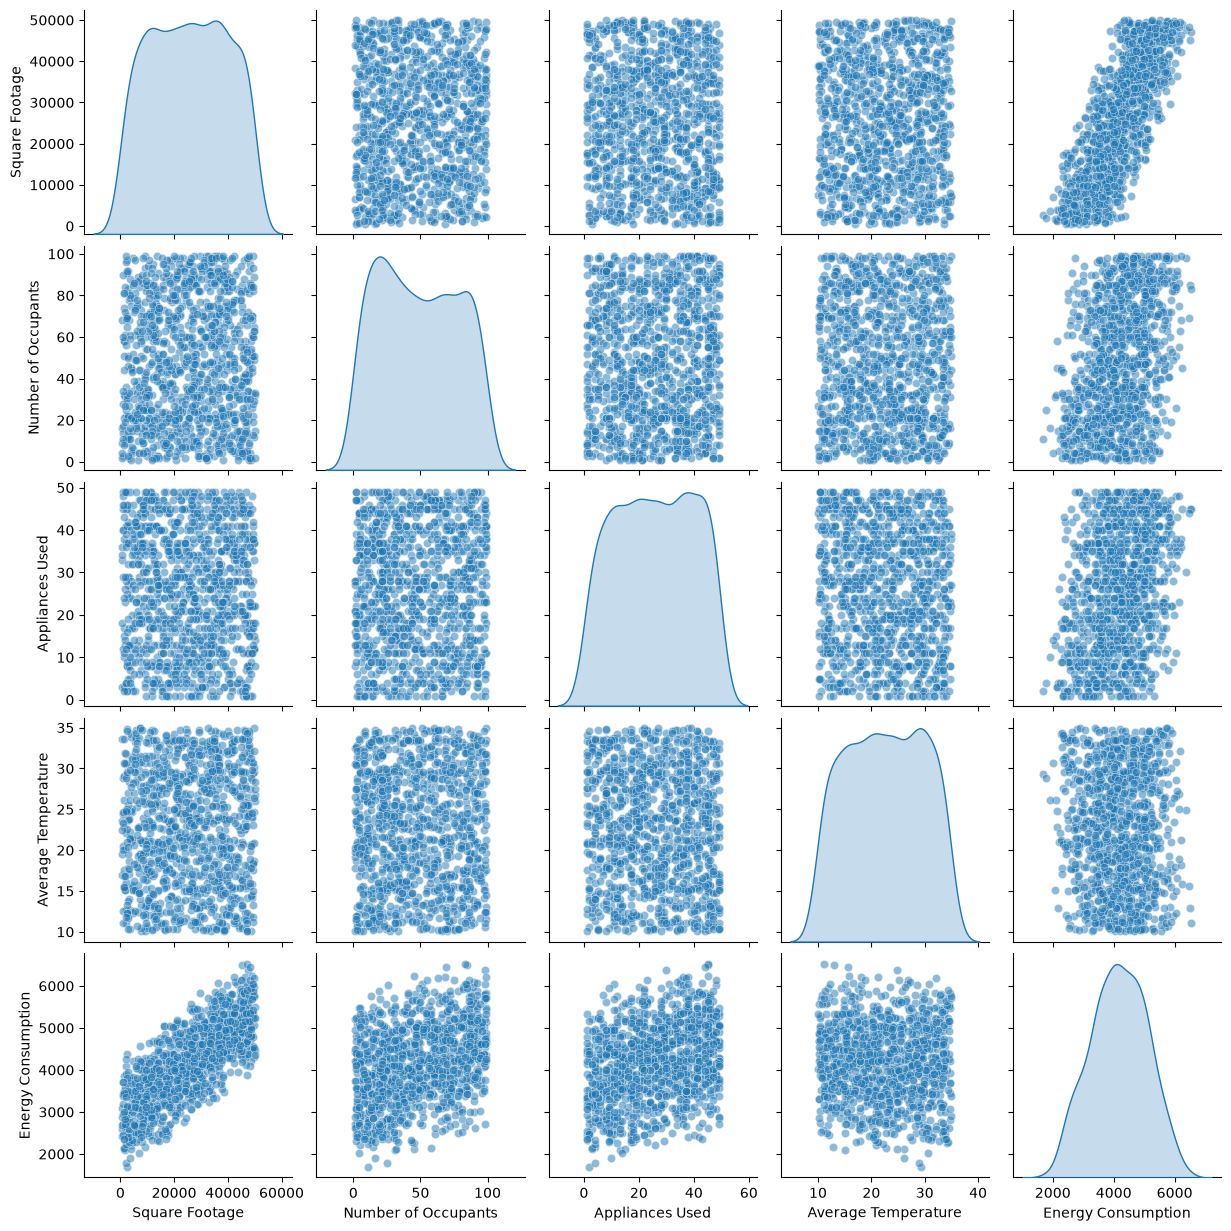

In [20]:
sns.pairplot(data[num_cols], diag_kind='kde', kind='scatter', plot_kws={'alpha': 0.5})  

FEATURE ENGINEERING >>
   

1.FEATURE TRANSFORMATION

implimenting train_test _split

In [21]:
from sklearn.model_selection import train_test_split
X = data[['Building Type', 'Square Footage', 'Number of Occupants',
          'Appliances Used', 'Average Temperature', 'Day of Week']]
y = data['Energy Consumption']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)


i  found no feature construction to perform on this data

now handling outliers

In [22]:
X_train.shape

(880, 6)

In [23]:

mean=X_train['Square Footage'].mean()
std=X_train['Square Footage'].std()
print(X_train['Square Footage'].min())
print(X_train['Square Footage'].max())

560
49997


In [24]:
X_train[X_train['Square Footage'] < (X_train['Square Footage']-mean)/3*std]

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week
551,Commercial,27205,44,14,11.38,Weekend
6,Industrial,38638,92,14,21.01,Weekend
584,Commercial,28029,38,15,18.72,Weekend
941,Residential,47324,30,32,25.49,Weekend
879,Industrial,41735,5,39,15.27,Weekend
...,...,...,...,...,...,...
769,Residential,47690,39,11,33.49,Weekday
871,Industrial,49151,45,45,15.80,Weekend
330,Residential,41589,50,34,33.20,Weekday
1044,Residential,36642,36,32,11.17,Weekend


<Axes: xlabel='Number of Occupants', ylabel='Energy Consumption'>

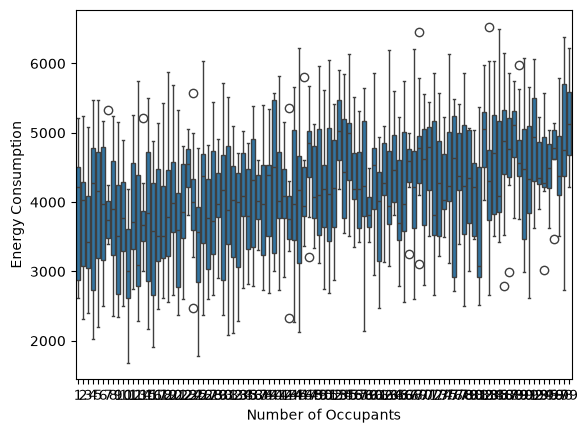

In [30]:
sns.boxplot(x='Number of Occupants', y='Energy Consumption', data=data)

In [50]:
X_train.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
507,23650,82,29,20,0,1,0
551,27205,44,14,11,0,0,1
290,7424,25,47,14,0,0,0
2,19255,37,17,14,1,0,1
6,38638,92,14,21,1,0,1


In [51]:
X_test=pd.get_dummies(X_test,columns=['Building Type','Day of Week'],drop_first=True).astype(int)

In [49]:
X_train=pd.get_dummies(X_train,columns=['Building Type','Day of Week'],drop_first=True).astype(int)


KeyError: "None of [Index(['Building Type', 'Day of Week'], dtype='str')] are in the [columns]"

In [40]:
X_train.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
507,23650,82,29,20,0,1,0
551,27205,44,14,11,0,0,1
290,7424,25,47,14,0,0,0
2,19255,37,17,14,1,0,1
6,38638,92,14,21,1,0,1


In [42]:
X_train.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
count,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000
mean,25456.946591,48.498864,25.296591,22.076136,0.328409,0.346591,0.505682
std,14171.391982,29.038948,14.106840,7.075242,0.469902,0.476155,0.500252
min,560.000000,1.000000,1.000000,10.000000,0.000000,0.000000,0.000000
25%,13280.500000,22.000000,13.000000,16.000000,0.000000,0.000000,0.000000
50%,25967.500000,47.000000,26.000000,22.000000,0.000000,0.000000,1.000000
75%,36992.500000,73.000000,37.000000,28.000000,1.000000,1.000000,1.000000
max,49997.000000,99.000000,49.000000,34.000000,1.000000,1.000000,1.000000


In [43]:
from sklearn.preprocessing import StandardScaler
stnd_scaler=StandardScaler()

In [46]:
stnd_scaler.fit(X_train)

StandardScaler()

In [52]:
X_train_scaled=stnd_scaler.transform(X_train)
X_test_scaled=stnd_scaler.transform(X_test)

In [54]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [58]:
X_train.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
count,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000
mean,25456.946591,48.498864,25.296591,22.076136,0.328409,0.346591,0.505682
std,14171.391982,29.038948,14.106840,7.075242,0.469902,0.476155,0.500252
min,560.000000,1.000000,1.000000,10.000000,0.000000,0.000000,0.000000
25%,13280.500000,22.000000,13.000000,16.000000,0.000000,0.000000,0.000000
50%,25967.500000,47.000000,26.000000,22.000000,0.000000,0.000000,1.000000
75%,36992.500000,73.000000,37.000000,28.000000,1.000000,1.000000,1.000000
max,49997.000000,99.000000,49.000000,34.000000,1.000000,1.000000,1.000000


In [60]:
np.round(X_train_scaled.describe(),1)

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
count,880.0,880.0,880.0,880.0,880.0,880.0,880.0
mean,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0
min,-1.8,-1.6,-1.7,-1.7,-0.7,-0.7,-1.0
25%,-0.9,-0.9,-0.9,-0.9,-0.7,-0.7,-1.0
50%,0.0,-0.1,0.0,-0.0,-0.7,-0.7,1.0
75%,0.8,0.8,0.8,0.8,1.4,1.4,1.0
max,1.7,1.7,1.7,1.7,1.4,1.4,1.0


<Axes: ylabel='Square Footage'>

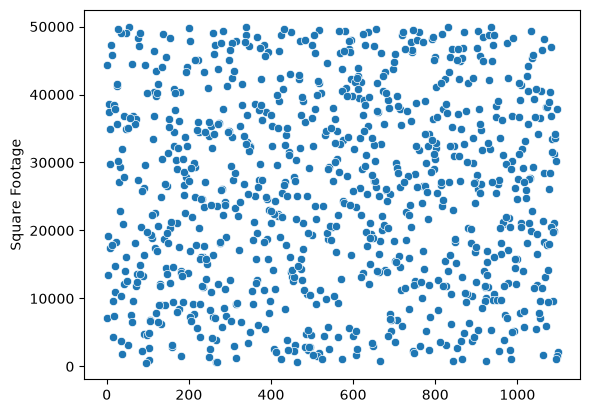

In [67]:

sns.scatterplot(X_train['Square Footage'])


<Axes: ylabel='Square Footage'>

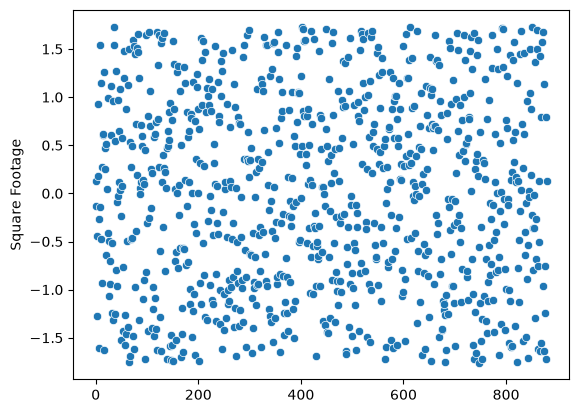

In [68]:

sns.scatterplot(X_train_scaled['Square Footage'])

In [72]:
data.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17
